## Import Libraries

In [36]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor, AdaBoostClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# load main dataset
data = pd.read_csv('processed_data.csv')

# load encoders file
with open('encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

# get encoder objects
# The kernel state shows `encoders` is `(LabelEncoder(), LabelEncoder())`
# Assign le_genre and le_prev_genre from the tuple.
# le_transition is not in the tuple and is handled separately later (assigned 0 in 'not_watched').
if isinstance(encoders, tuple) and len(encoders) >= 2:
    le_genre = encoders[0]
    le_prev_genre = encoders[1]
else:
    # Fallback or error handling if encoders is not the expected format
    raise ValueError(
        f"Expected 'encoders' to be a tuple of at least two LabelEncoder instances, "
        f"but got {type(encoders)} with length {len(encoders) if isinstance(encoders, (list, tuple)) else 'N/A'}. "
        "Please ensure 'encoders.pkl' is correctly generated with `le_genre` and `le_prev_genre`."
    )

# load data
movies =pd.read_csv('movies.csv')
rating =pd.read_csv('ratings.csv')

## clean data

In [5]:
print(data.head())
print(data.columns)
print(data.isnull().sum())

   userId  movieId  rating  timestamp             datetime  year  month  \
0       1      804     4.0  964980499  2000-07-30 18:08:19  2000      7   
1       1     1210     5.0  964980499  2000-07-30 18:08:19  2000      7   
2       1     2018     5.0  964980523  2000-07-30 18:08:43  2000      7   
3       1     2628     4.0  964980523  2000-07-30 18:08:43  2000      7   
4       1     2826     4.0  964980523  2000-07-30 18:08:43  2000      7   

                                               title  \
0                               She's the One (1996)   
1  Star Wars: Episode VI - Return of the Jedi (1983)   
2                                       Bambi (1942)   
3   Star Wars: Episode I - The Phantom Menace (1999)   
4                           13th Warrior, The (1999)   

                     genres primary_genre prev_genre     genre_transition  \
0            Comedy|Romance        Comedy        NaN       None -> Comedy   
1   Action|Adventure|Sci-Fi        Action     Comedy     C

##  Define Features and Target

In [6]:
# inputs or features
X = data[['userId','movieId','year','month',
          'genre_enc','prev_genre_enc','transition_enc',
          'user_avg_rating','movie_avg_rating']]
# ouput or target
y = data['rating'].round().clip(1,5).astype(int)
# features in list
FEATURES = X.columns.tolist()


In [7]:
# xtrain is used for data it has trained on
# xtest is new set of data to test the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# For logistic regression
y_cls_train = y_train.copy()
y_cls_test = y_test.copy()
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 80 dataset in training and 20 dataset in testing
print("Train rows:", len(X_train))
print("Test rows :", len(X_test))

Train rows: 80668
Test rows : 20168


## Model A — Logistic Regression


In [12]:
# max_iter=500 gives the model enough steps to converge
# C=1.0 is for regularisation
log_model = LogisticRegression(max_iter=500, C=1.0, random_state=42)
# Used scaled data here
log_model.fit(X_train_scaled, y_cls_train)

LogisticRegression(max_iter=500, random_state=42)

### Evaluate — Logistic Regression

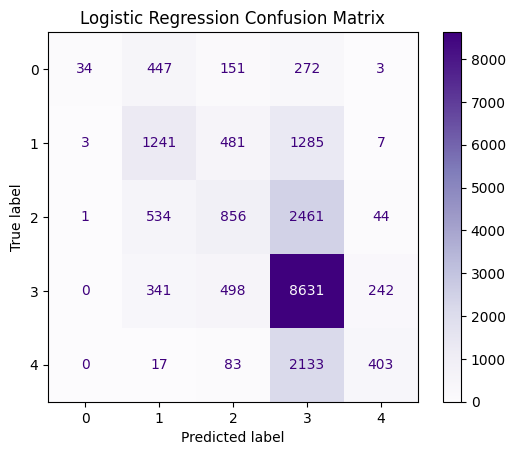

Accuracy : 0.5536
RMSE     : 0.9216
MAE      : 0.5707
R²       : 0.2138
Detailed Classification Report
              precision    recall  f1-score   support

          1★       0.89      0.04      0.07       907
          2★       0.48      0.41      0.44      3017
          3★       0.41      0.22      0.29      3896
          4★       0.58      0.89      0.70      9712
          5★       0.58      0.15      0.24      2636

    accuracy                           0.55     20168
   macro avg       0.59      0.34      0.35     20168
weighted avg       0.55      0.55      0.50     20168



In [13]:
log_preds = log_model.predict(X_test_scaled)
# Classification metrics
log_acc  = accuracy_score(y_cls_test,log_preds)

log_rmse = np.sqrt(mean_squared_error(y_test, log_preds))
log_mae  = mean_absolute_error(y_test, log_preds)
log_r2   = r2_score(y_test, log_preds)

# Confusion Matrix for Logistic Regression
cm_log = confusion_matrix(y_cls_test, log_preds)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot(cmap='Purples')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(f'Accuracy : {log_acc:.4f}')
print(f'RMSE     : {log_rmse:.4f}')
print(f'MAE      : {log_mae:.4f}')
print(f'R²       : {log_r2:.4f}')

print('Detailed Classification Report')
print(classification_report(y_cls_test, log_preds, target_names=['1★','2★','3★','4★','5★']))

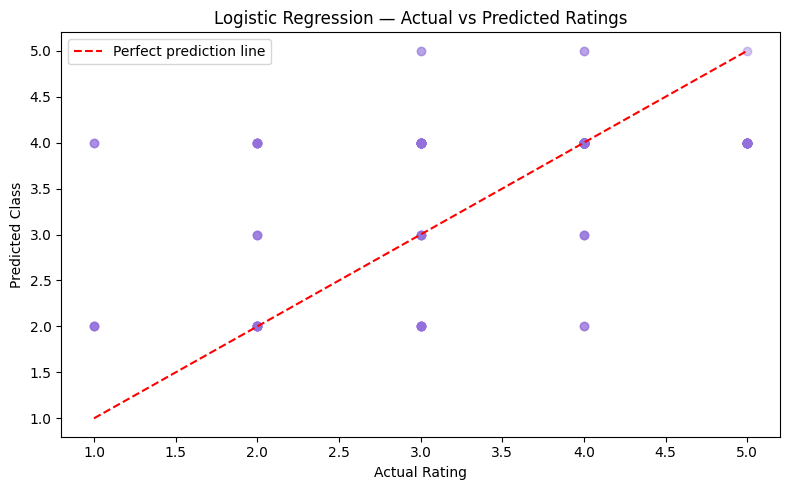

In [14]:
# Plot: Actual vs Predicted (scatter — shows class clustering)
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], log_preds[sample], alpha=0.4, color='mediumpurple')
plt.plot([1, 5], [1, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('Logistic Regression — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Class')
plt.legend()
plt.tight_layout()
plt.show()

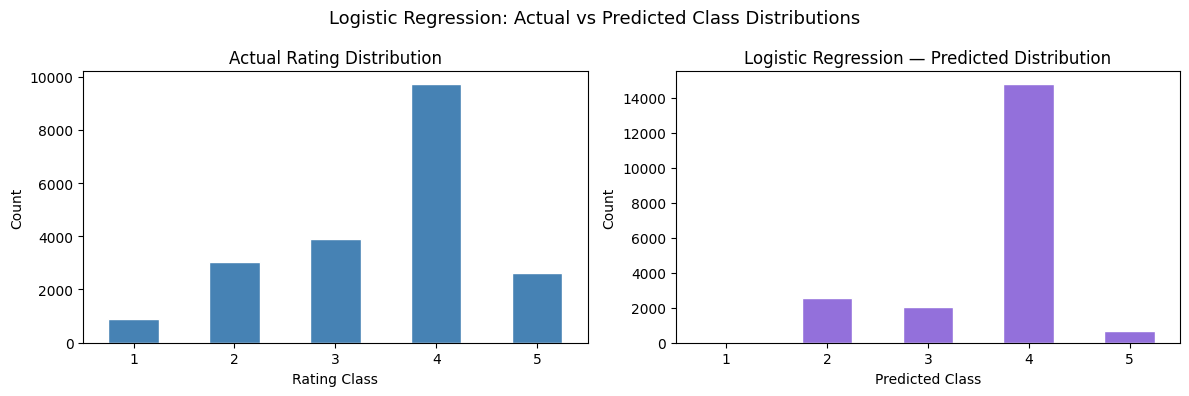

In [15]:
# Plot: Prediction Distribution
# Shows how often the model predicted each rating class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_cls_test).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Actual Rating Distribution')
axes[0].set_xlabel('Rating Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
pd.Series(log_preds).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white'
)
axes[1].set_title('Logistic Regression — Predicted Distribution')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Logistic Regression: Actual vs Predicted Class Distributions', fontsize=13)
plt.tight_layout()
plt.show()


## Model B — Support Vector Machine (SVR)
SVM for regression is called SVR


In [16]:
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.5)
svm_model.fit(X_train_scaled, y_train)

SVR(epsilon=0.5)

### Evaluate — SVR

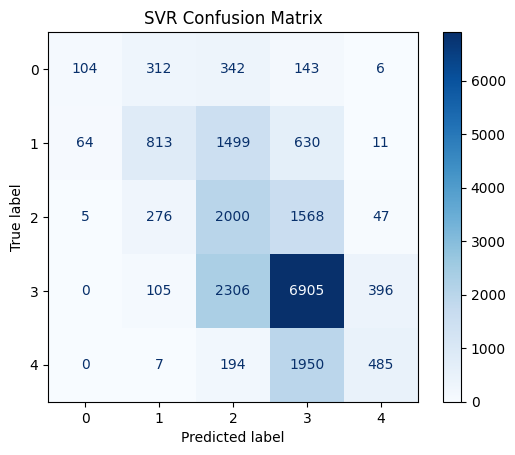

RMSE : 0.8188
MAE  : 0.6286
R²   : 0.3795


In [17]:
svm_preds = svm_model.predict(X_test_scaled)
svm_preds = np.clip(svm_preds, 0.5, 5.0)

# Round and clip y_test and svm_preds for confusion matrix
y_test_rounded = y_test.round().clip(1, 5).astype(int)
svm_preds_rounded = np.clip(svm_preds.round(), 1, 5).astype(int)

svm_rmse = np.sqrt(mean_squared_error(y_test, svm_preds))
svm_mae  = mean_absolute_error(y_test, svm_preds)
svm_r2   = r2_score(y_test, svm_preds)

# Confusion Matrix for SVR
cm_svm = confusion_matrix(y_test_rounded, svm_preds_rounded)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap='Blues')
plt.title("SVR Confusion Matrix")
plt.show()

print(f'RMSE : {svm_rmse:.4f}')
print(f'MAE  : {svm_mae:.4f}')
print(f'R²   : {svm_r2:.4f}')

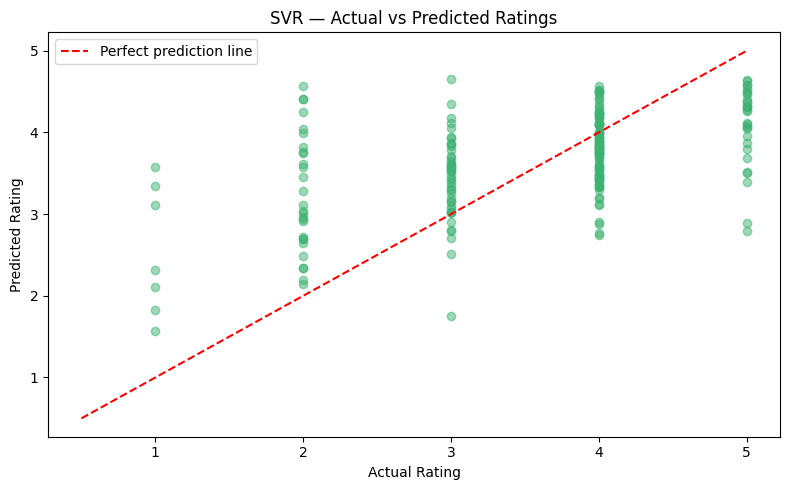

In [18]:
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], svm_preds[sample], alpha=0.5, color='mediumseagreen')
plt.plot([0.5, 5], [0.5, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('SVR — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

##Model C: K-Nearest Neighbours (KNN)

In [46]:
knn_model = KNeighborsRegressor(n_neighbors=10, metric='euclidean', n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor(metric='euclidean', n_jobs=-1, n_neighbors=10)

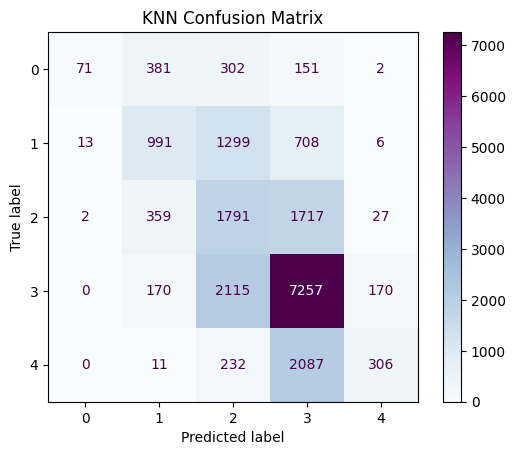

RMSE : 0.8330 
MAE  : 0.6287
R²   : 0.3578
['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis

In [66]:
knn_preds = knn_model.predict(X_test_scaled)
knn_preds = np.clip(knn_preds, 0.5, 5.0)

# Round and clip y_test and knn_preds for confusion matrix
y_test_rounded = y_test.round().clip(1, 5).astype(int)
knn_preds_rounded = np.clip(knn_preds.round(), 1, 5).astype(int)

knn_rmse = np.sqrt(mean_squared_error(y_test, knn_preds))
knn_mae  = mean_absolute_error(y_test, knn_preds)
knn_r2   = r2_score(y_test, knn_preds)

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test_rounded, knn_preds_rounded)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(cmap='BuPu')
plt.title("KNN Confusion Matrix")
plt.show()

print(f'RMSE : {knn_rmse:.4f} ')
print(f'MAE  : {knn_mae:.4f}')
print(f'R²   : {knn_r2:.4f}')

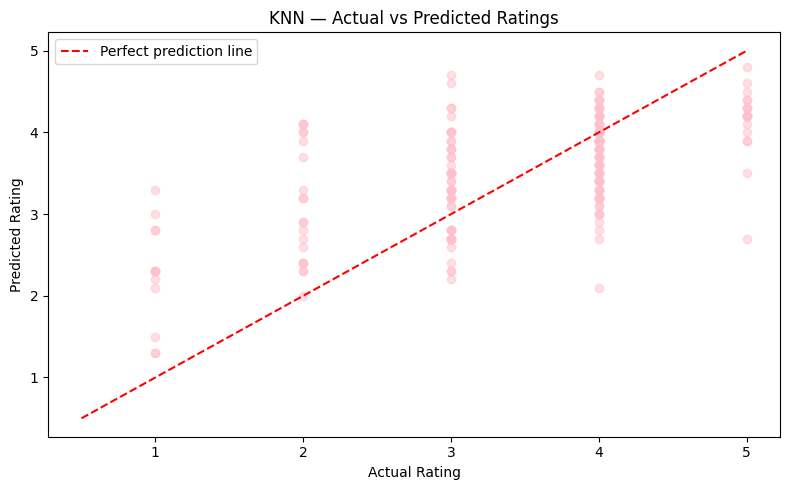

In [67]:
# Plot: Actual vs Predicted
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], knn_preds[sample], alpha=0.5, color='pink')
plt.plot([0.5, 5], [0.5, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('KNN — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

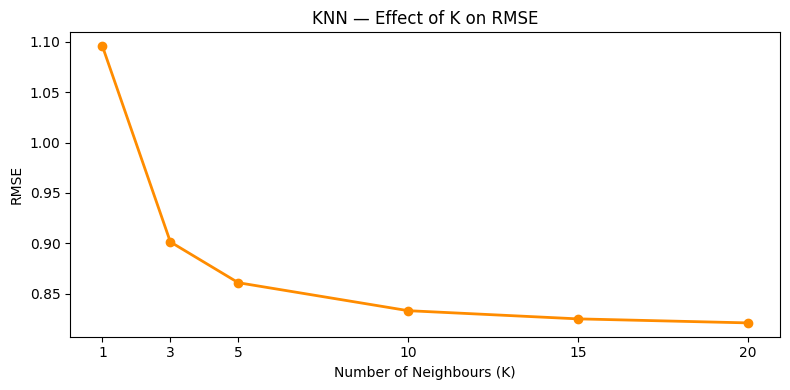

Best K by RMSE: 20  (RMSE = 0.8208)


In [22]:
# Plot: Effect of K on RMSE
k_values   = [1, 3, 5, 10, 15, 20]
k_rmse     = []

for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k, metric='euclidean', n_jobs=-1)
    m.fit(X_train_scaled, y_train)
    preds = np.clip(m.predict(X_test_scaled), 0.5, 5.0)
    k_rmse.append(np.sqrt(mean_squared_error(y_test, preds)))
plt.figure(figsize=(8, 4))
plt.plot(k_values, k_rmse, marker='o', color='darkorange', linewidth=2)
plt.title('KNN — Effect of K on RMSE')
plt.xlabel('Number of Neighbours (K)')
plt.ylabel('RMSE')
plt.xticks(k_values)
plt.tight_layout()
plt.show()
best_k = k_values[int(np.argmin(k_rmse))]
print(f'Best K by RMSE: {best_k}  (RMSE = {min(k_rmse):.4f})')

## Model D : Decision Tree Regressor

In [23]:
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)

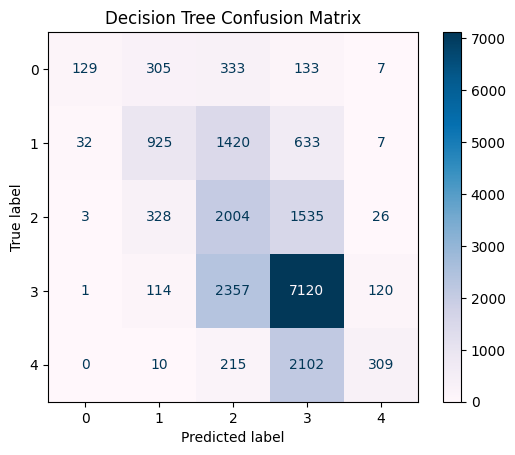

RMSE : 0.8173
MAE  : 0.6116
R²   : 0.3817


In [93]:
dt_preds = dt_model.predict(X_test)
dt_preds = np.clip(dt_preds, 0.5, 5.0)

# Round and clip y_test and dt_preds for confusion matrix
y_test_rounded = y_test.round().clip(1, 5).astype(int)
dt_preds_rounded = np.clip(dt_preds.round(), 1, 5).astype(int)

#regression matrix
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_mae  = mean_absolute_error(y_test, dt_preds)
dt_r2   = r2_score(y_test, dt_preds)

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test_rounded, dt_preds_rounded)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap='PuBu')
plt.title("Decision Tree Confusion Matrix")
plt.show()

print(f'RMSE : {dt_rmse:.4f}')
print(f'MAE  : {dt_mae:.4f}')
print(f'R²   : {dt_r2:.4f}')

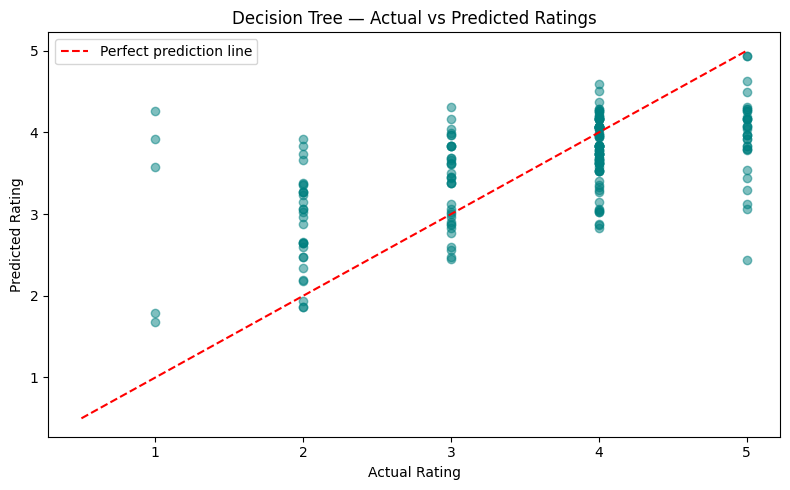

In [25]:
# Plot: Actual vs Predicted
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], dt_preds[sample], alpha=0.5, color='teal')
plt.plot([0.5, 5], [0.5, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('Decision Tree — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

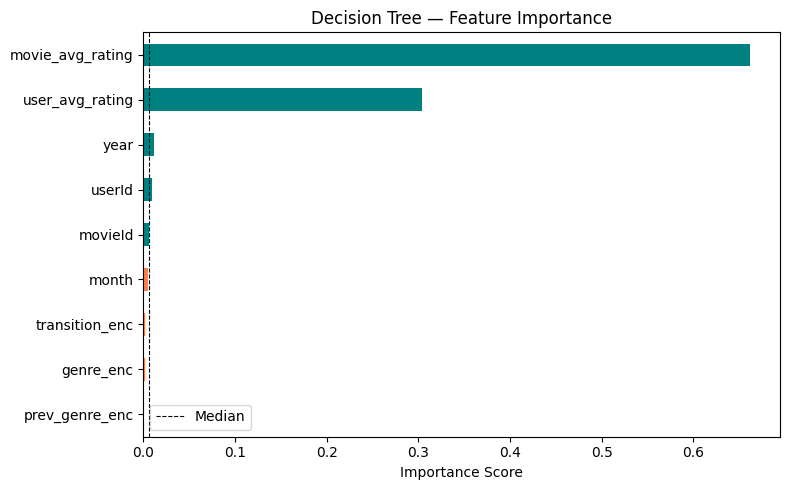

In [26]:
# Plot: Feature Importance
feat_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
feat_imp.plot(
    kind='barh',
    color=['coral' if v < feat_imp.median() else 'teal' for v in feat_imp]
)
plt.title('Decision Tree — Feature Importance')
plt.xlabel('Importance Score')
plt.axvline(feat_imp.median(), color='black', linewidth=0.8, linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.show()

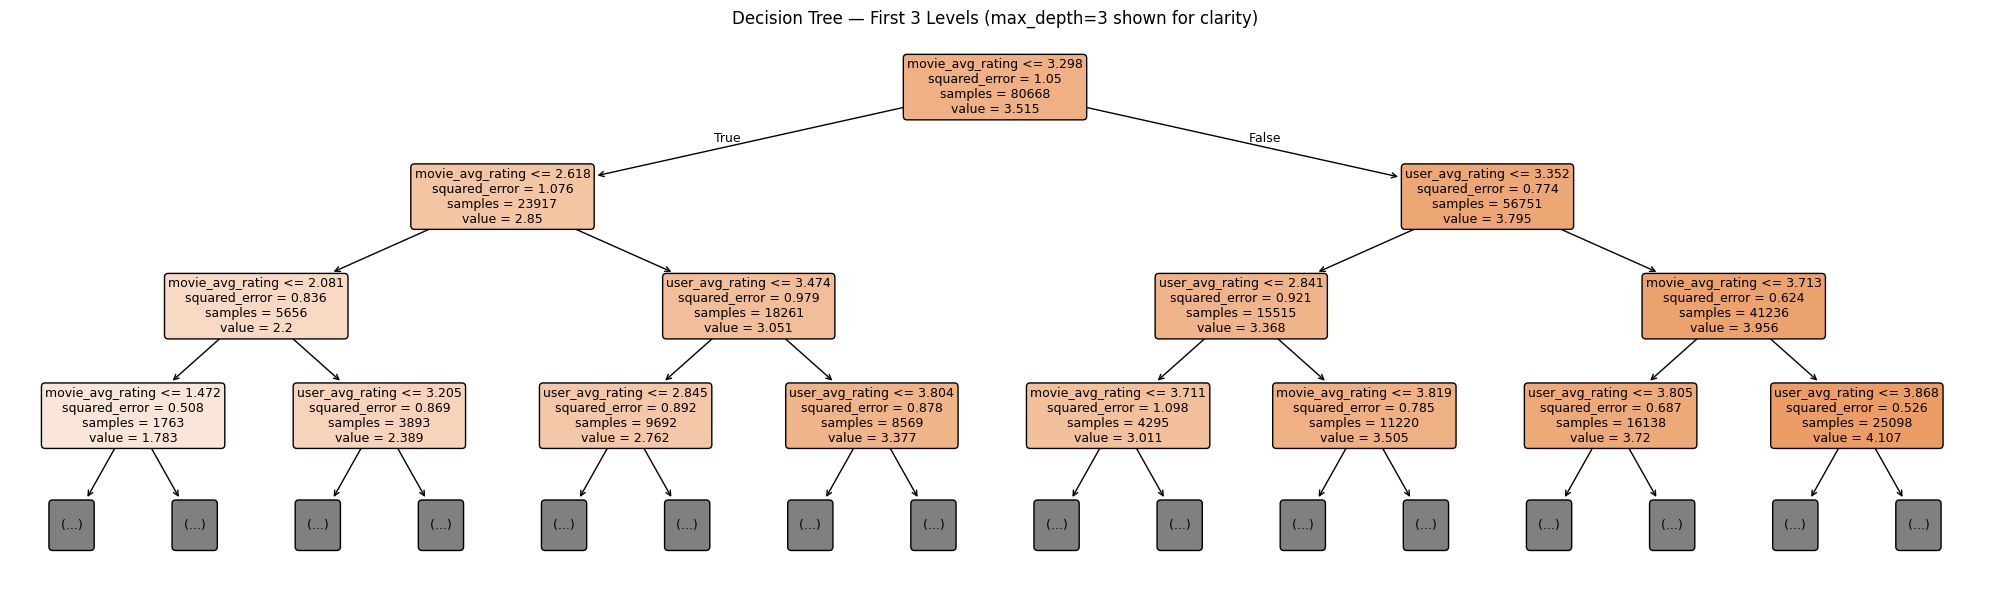

In [27]:
# Plot: Top 3 levels of the Decision Tree
plt.figure(figsize=(20, 6))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=FEATURES,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — First 3 Levels (max_depth=3 shown for clarity)')
plt.tight_layout()
plt.show()

## Model E : Random Forest Regressor

In [28]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                  min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=20, n_jobs=-1,
                      random_state=42)

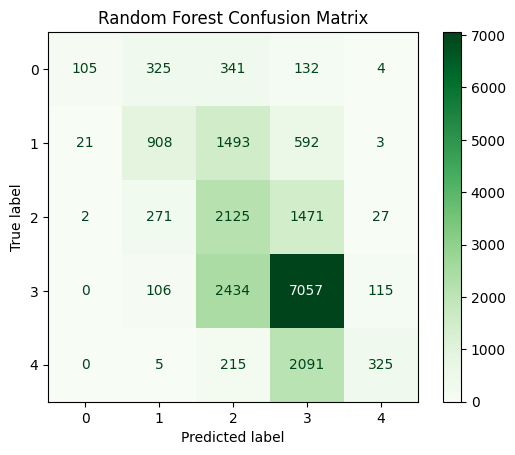

RMSE : 0.8051
MAE  : 0.6041
R²   : 0.4001


In [68]:
rf_preds = rf_model.predict(X_test)
rf_preds = np.clip(rf_preds, 0.5, 5.0)

# Round and clip y_test and rf_preds for confusion matrix
y_test_rounded   = y_test.round().clip(1, 5).astype(int)
rf_preds_rounded = np.clip(rf_preds.round(), 1, 5).astype(int)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test_rounded, rf_preds_rounded)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

print(f'RMSE : {rf_rmse:.4f}')
print(f'MAE  : {rf_mae:.4f}')
print(f'R²   : {rf_r2:.4f}')

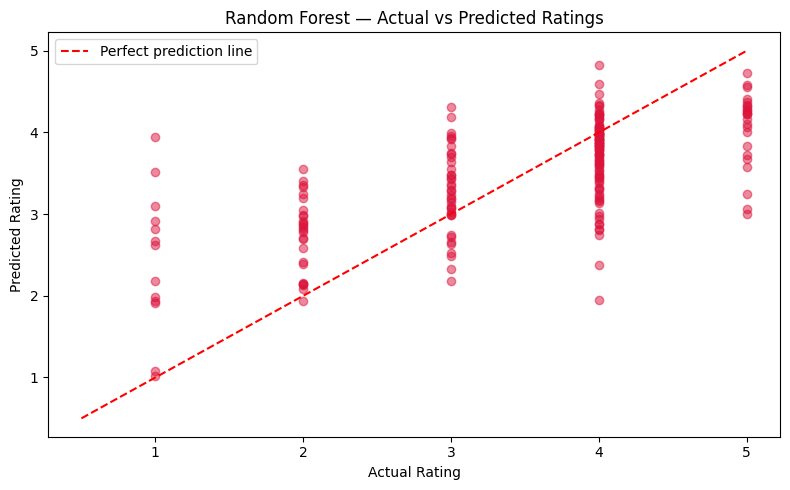

In [30]:
# Plot: Actual vs Predicted
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], rf_preds[sample], alpha=0.5, color='crimson')
plt.plot([0.5, 5], [0.5, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('Random Forest — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

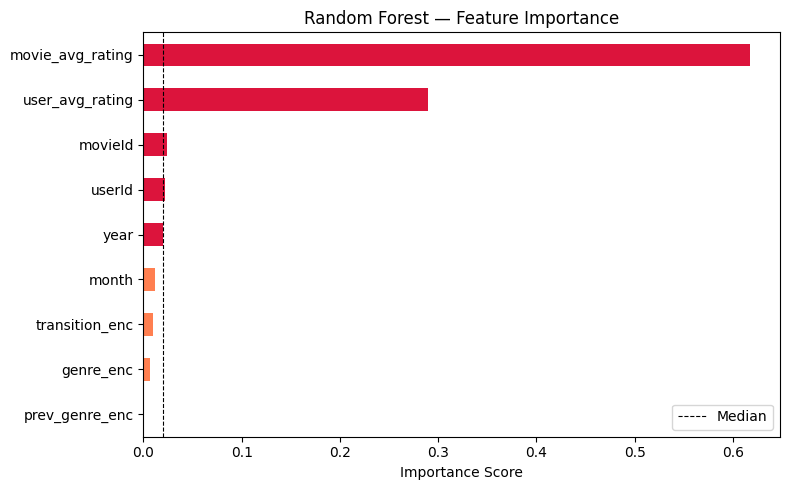

In [31]:
# Plot: Feature Importance
feat_imp_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
feat_imp_rf.plot(
    kind='barh',
    color=['coral' if v < feat_imp_rf.median() else 'crimson' for v in feat_imp_rf]
)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.axvline(feat_imp_rf.median(), color='black', linewidth=0.8, linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.show()

## Model F — Bagging Regressor
Bagging (Bootstrap Aggregating) wraps Decision Tree base estimators to reduce variance.

In [ ]:
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)
bag_model.fit(X_train, y_train)

In [ ]:
bag_preds = bag_model.predict(X_test)
bag_preds = np.clip(bag_preds, 0.5, 5.0)

y_test_rounded   = y_test.round().clip(1, 5).astype(int)
bag_preds_rounded = np.clip(bag_preds.round(), 1, 5).astype(int)

bag_rmse = np.sqrt(mean_squared_error(y_test, bag_preds))
bag_mae  = mean_absolute_error(y_test, bag_preds)
bag_r2   = r2_score(y_test, bag_preds)

cm_bag = confusion_matrix(y_test_rounded, bag_preds_rounded)
disp_bag = ConfusionMatrixDisplay(confusion_matrix=cm_bag)
disp_bag.plot(cmap='YlOrBr')
plt.title('Bagging Regressor Confusion Matrix')
plt.show()

print(f'RMSE : {bag_rmse:.4f}')
print(f'MAE  : {bag_mae:.4f}')
print(f'R²   : {bag_r2:.4f}')

In [ ]:
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], bag_preds[sample], alpha=0.5, color='goldenrod')
plt.plot([0.5, 5], [0.5, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('Bagging Regressor — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

## Model G — Gradient Boosting Regressor
Boosting builds trees sequentially, each correcting errors of the previous — ideal for reducing bias.

In [ ]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)
gbr_model.fit(X_train, y_train)

In [ ]:
gbr_preds = gbr_model.predict(X_test)
gbr_preds = np.clip(gbr_preds, 0.5, 5.0)

y_test_rounded    = y_test.round().clip(1, 5).astype(int)
gbr_preds_rounded = np.clip(gbr_preds.round(), 1, 5).astype(int)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_preds))
gbr_mae  = mean_absolute_error(y_test, gbr_preds)
gbr_r2   = r2_score(y_test, gbr_preds)

cm_gbr = confusion_matrix(y_test_rounded, gbr_preds_rounded)
disp_gbr = ConfusionMatrixDisplay(confusion_matrix=cm_gbr)
disp_gbr.plot(cmap='Oranges')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

print(f'RMSE : {gbr_rmse:.4f}')
print(f'MAE  : {gbr_mae:.4f}')
print(f'R²   : {gbr_r2:.4f}')

In [ ]:
# Plot: Feature Importance
feat_imp_gbr = pd.Series(gbr_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
feat_imp_gbr.plot(
    kind='barh',
    color=['lightsalmon' if v < feat_imp_gbr.median() else 'darkorange' for v in feat_imp_gbr]
)
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance Score')
plt.axvline(feat_imp_gbr.median(), color='black', linewidth=0.8, linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], gbr_preds[sample], alpha=0.5, color='darkorange')
plt.plot([0.5, 5], [0.5, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('Gradient Boosting — Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

## Model H — AdaBoost Classifier (Boosting)
AdaBoost (Adaptive Boosting) trains weak classifiers sequentially, each focusing on previously misclassified samples — ideal for boosting classification accuracy on discrete rating labels.

In [ ]:
# AdaBoostClassifier uses DecisionTreeClassifier (max_depth=1) as default weak learner
# n_estimators=200 ensures sufficient boosting rounds
# learning_rate=0.5 balances each estimator's contribution
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)
# Uses scaled data — same as Logistic Regression
ada_model.fit(X_train_scaled, y_cls_train)


In [ ]:
ada_preds = ada_model.predict(X_test_scaled)

# Classification metrics
ada_acc  = accuracy_score(y_cls_test, ada_preds)

ada_rmse = np.sqrt(mean_squared_error(y_test, ada_preds))
ada_mae  = mean_absolute_error(y_test, ada_preds)
ada_r2   = r2_score(y_test, ada_preds)

# Confusion Matrix for AdaBoost
cm_ada = confusion_matrix(y_cls_test, ada_preds)
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada)
disp_ada.plot(cmap='RdPu')
plt.title('AdaBoost Confusion Matrix')
plt.show()

print(f'Accuracy : {ada_acc:.4f}')
print(f'RMSE     : {ada_rmse:.4f}')
print(f'MAE      : {ada_mae:.4f}')
print(f'R\u00b2       : {ada_r2:.4f}')

print('Detailed Classification Report')
print(classification_report(y_cls_test, ada_preds, target_names=['1\u2605','2\u2605','3\u2605','4\u2605','5\u2605']))


In [ ]:
# Plot: Actual vs Predicted (scatter)
sample = np.random.choice(len(y_test), 200, replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.values[sample], ada_preds[sample], alpha=0.4, color='darkviolet')
plt.plot([1, 5], [1, 5], color='red', linestyle='--', label='Perfect prediction line')
plt.title('AdaBoost \u2014 Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Class')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Plot: Prediction Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_cls_test).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Actual Rating Distribution')
axes[0].set_xlabel('Rating Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
pd.Series(ada_preds).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='darkviolet', edgecolor='white'
)
axes[1].set_title('AdaBoost \u2014 Predicted Distribution')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('AdaBoost: Actual vs Predicted Class Distributions', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Plot: AdaBoost Feature Importance (estimator weights)
feat_imp_ada = pd.Series(ada_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
feat_imp_ada.plot(
    kind='barh',
    color=['plum' if v < feat_imp_ada.median() else 'darkviolet' for v in feat_imp_ada]
)
plt.title('AdaBoost \u2014 Feature Importance')
plt.xlabel('Importance Score')
plt.axvline(feat_imp_ada.median(), color='black', linewidth=0.8, linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.show()


## Model Comparison

In [38]:
# Building a comparison table for all 8 models
comparison = pd.DataFrame({
    'Model' : ['Logistic Regression', 'SVR (SVM)', 'KNN', 'Decision Tree',
               'Random Forest', 'Bagging', 'Gradient Boosting', 'AdaBoost'],
    'RMSE'  : [log_rmse,  svm_rmse, knn_rmse, dt_rmse, rf_rmse, bag_rmse, gbr_rmse, ada_rmse],
    'MAE'   : [log_mae,   svm_mae,  knn_mae,  dt_mae,  rf_mae,  bag_mae,  gbr_mae,  ada_mae],
    'R\u00b2'    : [log_r2,    svm_r2,   knn_r2,   dt_r2,   rf_r2,   bag_r2,   gbr_r2,   ada_r2],
})
comparison = comparison.set_index('Model').round(4)
def highlight_best(col):
    if col.name == 'R\u00b2':
        return ['background-color: #839387' if v == col.max() else '' for v in col]
    else:
        return ['background-color: #839387' if v == col.min() else '' for v in col]

# all model comparison
display(comparison.style.apply(highlight_best))


,RMSE,MAE,R²
Model,,,
Logistic Regression,0.921600,0.570700,0.213800
SVR (SVM),0.818800,0.628600,0.379500
KNN,0.833000,0.628700,0.357800
Decision Tree,0.817300,0.611600,0.381700
Random Forest,0.805100,0.604100,0.400100


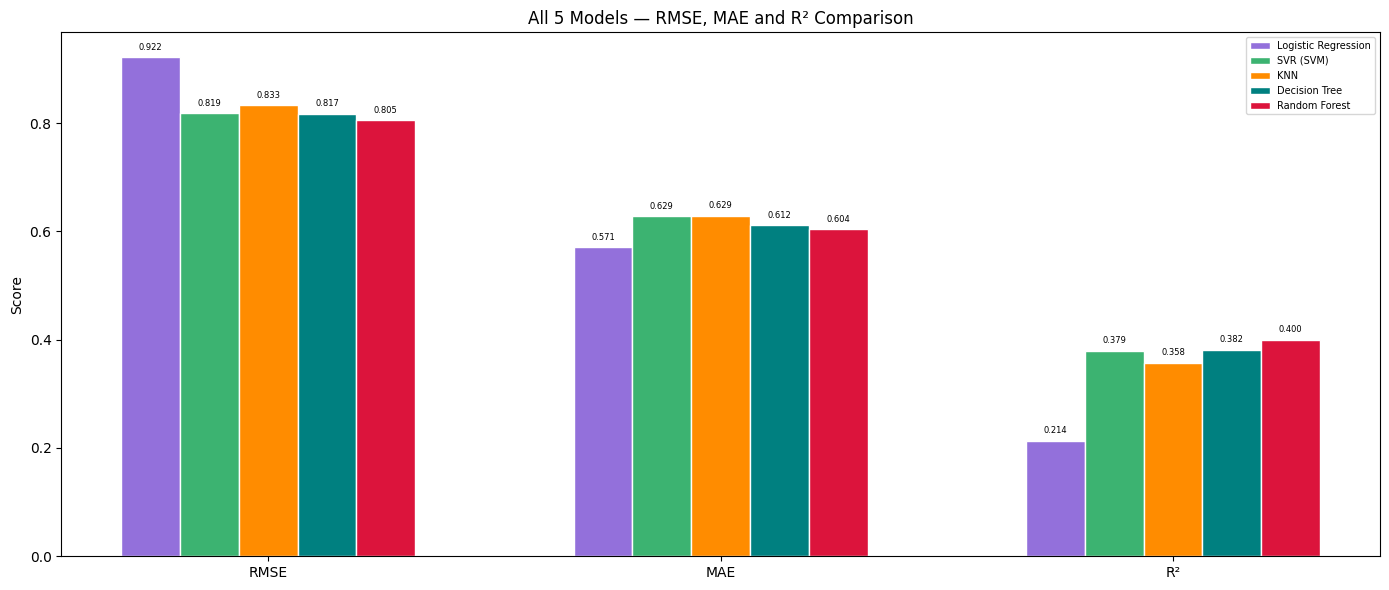


 Best RMSE  → Random Forest
Best R²    → Random Forest


In [39]:
# Visual comparison using grouped bar chart
metrics = ['RMSE', 'MAE', 'R\u00b2']
models  = ['Logistic Regression', 'SVR (SVM)', 'KNN', 'Decision Tree',
           'Random Forest', 'Bagging', 'Gradient Boosting', 'AdaBoost']
colors  = ['mediumpurple', 'mediumseagreen', 'darkorange', 'teal',
           'crimson', 'goldenrod', 'tomato', 'darkviolet']
values  = [
    [log_rmse, log_mae, log_r2],
    [svm_rmse, svm_mae, svm_r2],
    [knn_rmse, knn_mae, knn_r2],
    [dt_rmse,  dt_mae,  dt_r2],
    [rf_rmse,  rf_mae,  rf_r2],
    [bag_rmse, bag_mae, bag_r2],
    [gbr_rmse, gbr_mae, gbr_r2],
    [ada_rmse, ada_mae, ada_r2],
]

x     = np.arange(len(metrics))
width = 0.10

fig, ax = plt.subplots(figsize=(18, 6))
for i, (model, vals, color) in enumerate(zip(models, values, colors)):
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=5
        )

ax.set_xticks(x + width * 3.5)
ax.set_xticklabels(metrics)
ax.set_title('All 8 Models \u2014 RMSE, MAE and R\u00b2 Comparison')
ax.set_ylabel('Score')
ax.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

# conclusion
best_rmse = comparison['RMSE'].idxmin()
best_r2   = comparison['R\u00b2'].idxmax()
print(f'\n Best RMSE  \u2192 {best_rmse}')
print(f'Best R\u00b2    \u2192 {best_r2}')


## Generating Movie Recommendations


In [34]:
# Picking the most active user as demo
test_user = data['userId'].value_counts().index[0]
print(f'Generating recommendations for User ID:{test_user}')
print(f'This user has rated {len(data[data["userId"] == test_user])} movies already.')

Generating recommendations for User ID:414
This user has rated 2698 movies already.


In [40]:
# Find all movies this user has NOT watched yet
watched     = data[data['userId'] == test_user]['movieId'].unique()
not_watched = movies[~movies['movieId'].isin(watched)].copy()

# Get this user's last known info
user_history = data[data['userId'] == test_user].sort_values('timestamp')
last_genre   = user_history['primary_genre'].iloc[-1]
user_avg_val = user_history['rating'].mean()
last_year    = user_history['year'].iloc[-1]
last_month   = user_history['month'].iloc[-1]

movie_avg_dict = data.groupby('movieId')['rating'].mean().to_dict()

not_watched['primary_genre'] = not_watched['genres'].apply(
    lambda x: x.split('|')[0] if x != '(no genres listed)' else 'Unknown'
)

def safe_encode(encoder, value):
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    return 0

not_watched['genre_enc']        = not_watched['primary_genre'].apply(lambda g: safe_encode(le_genre, g))
not_watched['prev_genre_enc']   = safe_encode(le_prev_genre, last_genre)
not_watched['transition_enc']   = 0
not_watched['user_avg_rating']  = user_avg_val
not_watched['movie_avg_rating'] = not_watched['movieId'].apply(lambda m: movie_avg_dict.get(m, 3.5))
not_watched['userId']           = test_user
not_watched['year']             = last_year
not_watched['month']            = last_month

X_unseen = not_watched[FEATURES]
X_unseen_scaled = scaler.transform(X_unseen)

# Predict with all 8 models
not_watched['pred_logistic'] = log_model.predict(X_unseen).clip(1, 5).astype(float)
not_watched['pred_svm']      = np.clip(svm_model.predict(X_unseen_scaled), 0.5, 5.0).round(2)
not_watched['pred_knn']      = np.clip(knn_model.predict(X_unseen_scaled), 0.5, 5.0).round(2)
not_watched['pred_dt']       = np.clip(dt_model.predict(X_unseen), 0.5, 5.0).round(2)
not_watched['pred_rf']       = np.clip(rf_model.predict(X_unseen), 0.5, 5.0).round(2)
not_watched['pred_bag']      = np.clip(bag_model.predict(X_unseen), 0.5, 5.0).round(2)
not_watched['pred_gbr']      = np.clip(gbr_model.predict(X_unseen), 0.5, 5.0).round(2)
not_watched['pred_ada']      = ada_model.predict(X_unseen_scaled).clip(1, 5).astype(float)

# Pick the best model by RMSE
best_model_name = comparison['RMSE'].idxmin()
pred_col_map = {
    'Logistic Regression' : 'pred_logistic',
    'SVR (SVM)'           : 'pred_svm',
    'KNN'                 : 'pred_knn',
    'Decision Tree'       : 'pred_dt',
    'Random Forest'       : 'pred_rf',
    'Bagging'             : 'pred_bag',
    'Gradient Boosting'   : 'pred_gbr',
    'AdaBoost'            : 'pred_ada',
}
best_pred_col = pred_col_map[best_model_name]

# Top 10 recommendations
top10 = (
    not_watched
    .sort_values(best_pred_col, ascending=False)
    [['title', 'primary_genre',
      'pred_logistic', 'pred_svm', 'pred_knn', 'pred_dt',
      'pred_rf', 'pred_bag', 'pred_gbr', 'pred_ada']]
    .head(10)
    .reset_index(drop=True)
)
# starting rank as 1
top10.index += 1
top10.columns = ['Title', 'Genre',
                 'Logistic Reg', 'SVR', 'KNN', 'Decision Tree',
                 'Random Forest', 'Bagging', 'Grad. Boost', 'AdaBoost']

# Top 10 Recommended Movies for User
print(f'Ranked by best model: {best_model_name}')
display(top10)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Ranked by best model: Random Forest


,Title,Genre,Logistic Reg,SVR,KNN,Decision Tree,Random Forest
1,Lamerica (1994),Adventure,2.0,4.45,4.3,5.0,4.99
2,Won't You Be My Neighbor? (2018),Documentary,4.0,4.16,4.4,5.0,4.99
3,"Son of the Bride (Hijo de la novia, El) (2001)",Comedy,4.0,4.41,4.0,5.0,4.99
4,Dylan Moran: Monster (2004),Comedy,4.0,4.29,4.3,5.0,4.99
5,Satin Rouge (2002),Drama,4.0,4.33,4.2,5.0,4.99
6,Who Killed Chea Vichea? (2010),Documentary,4.0,4.19,4.5,5.0,4.99
7,SORI: Voice from the Heart (2016),Drama,4.0,4.14,4.5,5.0,4.99
8,Tenchi Muyô! In Love (1996),Animation,4.0,4.35,4.5,5.0,4.99
9,Ice Age: The Great Egg-Scapade (2016),Adventure,4.0,4.36,4.3,5.0,4.99
10,"Four Seasons, The (1981)",Comedy,4.0,4.41,4.0,5.0,4.99
